<a href="https://colab.research.google.com/github/giovannasantiagoo/unb/blob/main/MVP_SAD_Giovanna_Atividade2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Sistema de Apoio à Decisão: Risco, Custo e Tempo para Implementação de Nova Unidade

**Aluna:** Giovanna Rodrigues Santiago  
**Disciplina:** Sistemas de Apoio à Decisão  
**Universidade de Brasília (UnB)**

**Contexto do problema:** uma empresa de controle de dados (armazenamento em nuvem) está avaliando abrir uma nova unidade (um novo data center). Antes de decidir onde e como construir, a empresa precisa responder três perguntas:

| Eixo | Pergunta de decisão |
|---|---|
| **Risco** | Qual a chance de falha, dada a configuração escolhida? |
| **Custo** | Quanto custa operar essa configuração? |
| **Tempo** | Depois de quantos anos o equipamento degrada e exige renovação? |

A empresa controla, no momento do projeto (antes de qualquer servidor ligar), decisões como **região**, **tipo de servidor**, **tipo de refrigeração** e **fonte de energia**. A ideia deste MVP é usar dados de data centers já existentes para prever, para uma nova configuração, o risco e o custo esperados, apoiando a escolha antes de investir.

**Dataset:** [Hyperscale Data Center Dataset](https://www.kaggle.com/datasets/deeplumiere/hyperscale-data-center-dataset) (Kaggle), com dados simulados de telemetria de data centers hyperscale.

**Observação sobre este notebook:** os nomes exatos das colunas no arquivo baixado podem variar um pouco (letras maiúsculas/minúsculas, sublinhado no lugar de espaço, etc). Por isso, em vez de escrever os nomes fixos no código, as próximas células **descobrem sozinhas** quais colunas representam risco, custo, tempo e cada decisão de projeto, procurando por palavras-chave. Isso evita o erro de "coluna não encontrada".

## 1. Preparação do ambiente e acesso ao Kaggle

1. Entre em [kaggle.com](https://www.kaggle.com) e faça login
2. Clique na sua foto de perfil > **Settings** > aba **API Tokens**
3. Clique em **Create Legacy API Key** (baixa o arquivo `kaggle.json`)
4. Rode a célula abaixo e faça upload desse arquivo quando ela pedir

In [4]:
!pip install kagglehub -q

from google.colab import files
import os

print("Faça upload do arquivo kaggle.json:")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded.keys():
    os.rename(fname, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Chave configurada.")

Faça upload do arquivo kaggle.json:


Saving kaggle.json to kaggle.json
Chave configurada.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score, mean_absolute_error

sns.set(style="whitegrid")

## 2. Carga dos dados

In [6]:
import kagglehub

path = kagglehub.dataset_download("deeplumiere/hyperscale-data-center-dataset")
print("Arquivos baixados em:", path)
print(os.listdir(path))

100%|██████████| 7.46M/7.46M [00:01<00:00, 6.91MB/s]

Extracting files...


Arquivos baixados em: /root/.cache/kagglehub/datasets/deeplumiere/hyperscale-data-center-dataset/versions/1
['correlation_matrix.csv', 'dataset_metadata.json', 'dataset_summary.txt', 'green_ai_datacenter.csv']


In [7]:
csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
print("Arquivo(s) CSV encontrado(s):", csv_files)

# a pasta baixada tem mais de um CSV (ex: uma matriz de correlação à parte).
# escolhemos o maior arquivo, que é a base de dados completa, não um resumo.
csv_escolhido = max(csv_files, key=lambda f: os.path.getsize(os.path.join(path, f)))
print("Arquivo escolhido (o maior, base completa):", csv_escolhido)

# keep_default_na=False evita que siglas como "NA" (North America) sejam lidas como valor ausente
df = pd.read_csv(os.path.join(path, csv_escolhido), keep_default_na=False, na_values=[""])
print("Formato:", df.shape)
print()
print("Colunas encontradas no arquivo:")
print(df.columns.tolist())

Arquivo(s) CSV encontrado(s): ['correlation_matrix.csv', 'green_ai_datacenter.csv']
Arquivo escolhido (o maior, base completa): green_ai_datacenter.csv
Formato: (100000, 35)

Colunas encontradas no arquivo:
['server_type', 'cooling_type', 'datacenter_region', 'time_of_day', 'maintenance_status', 'energy_source_primary', 'server_age_years', 'rack_u_position', 'workload_intensity', 'cpu_utilization', 'gpu_utilization', 'memory_utilization', 'storage_utilization', 'disk_io_iops', 'network_throughput_gbps', 'network_latency_ms', 'virtual_machines_count', 'ambient_temperature_c', 'humidity_percentage', 'inlet_temperature_c', 'exhaust_temperature_c', 'fan_speed_rpm', 'airflow_cfm', 'cooling_efficiency', 'power_supply_efficiency', 'ups_battery_health', 'power_consumption_kw', 'pue', 'wue', 'carbon_intensity_gco2_kwh', 'renewable_energy_ratio', 'carbon_emission_kg', 'compute_cost_usd', 'energy_efficiency_class', 'failure_risk_level']


In [8]:
df.head()

,server_type,cooling_type,datacenter_region,time_of_day,maintenance_status,energy_source_primary,server_age_years,rack_u_position,workload_intensity,cpu_utilization,...,ups_battery_health,power_consumption_kw,pue,wue,carbon_intensity_gco2_kwh,renewable_energy_ratio,carbon_emission_kg,compute_cost_usd,energy_efficiency_class,failure_risk_level
0,Edge,Air,EU,Night,Normal,Solar,8,38,0.615,46.498,...,63.263,61.939,1.137,0.268,177.167,0.893,1.340,14.090,High,Medium
1,GPU,Liquid,EU,Off-Peak,Normal,Solar,2,17,0.295,21.285,...,88.992,206.840,1.050,2.353,198.353,0.723,11.935,43.436,High,Low
2,Compute,Hybrid,ME,Peak,Normal,Grid,3,1,0.683,52.201,...,78.130,96.127,1.050,0.220,444.571,0.015,44.217,10.093,Low,Low
3,Compute,Air,NA,Off-Peak,Normal,Grid,7,39,0.416,32.406,...,66.360,100.631,1.123,0.391,328.678,0.329,24.919,16.954,Low,Medium
4,GPU,Liquid,EU,Night,Normal,Hydro,2,24,0.278,27.067,...,94.749,218.814,1.050,1.779,190.772,0.767,10.219,45.951,High,Low


## 3. Descobrindo as colunas certas automaticamente

A função abaixo procura, entre os nomes reais das colunas, quais contêm cada palavra-chave. Assim não dependemos de adivinhar o nome exato.

In [9]:
def encontrar_colunas(df, palavras_chave):
    """Retorna as colunas cujo nome contém alguma das palavras-chave (ignorando maiúsculas/minúsculas e _)."""
    def normaliza(s):
        return s.lower().replace("_", "").replace(" ", "")
    return [c for c in df.columns if any(normaliza(p) in normaliza(c) for p in palavras_chave)]

col_risco_candidatas = encontrar_colunas(df, ["risk"])
col_custo_candidatas = encontrar_colunas(df, ["cost"])
col_idade_candidatas = encontrar_colunas(df, ["age", "years"])
col_regiao_candidatas = encontrar_colunas(df, ["region", "location", "country"])
col_servertype_candidatas = encontrar_colunas(df, ["server_type", "servertype", "type"])
col_cooling_candidatas = encontrar_colunas(df, ["cool"])
col_energia_candidatas = encontrar_colunas(df, ["energy", "power_source", "fuel"])

print("Candidatas a coluna de RISCO:", col_risco_candidatas)
print("Candidatas a coluna de CUSTO:", col_custo_candidatas)
print("Candidatas a coluna de IDADE/TEMPO:", col_idade_candidatas)
print("Candidatas a coluna de REGIÃO:", col_regiao_candidatas)
print("Candidatas a coluna de TIPO DE SERVIDOR:", col_servertype_candidatas)
print("Candidatas a coluna de REFRIGERAÇÃO:", col_cooling_candidatas)
print("Candidatas a coluna de ENERGIA:", col_energia_candidatas)

Candidatas a coluna de RISCO: ['failure_risk_level']
Candidatas a coluna de CUSTO: ['compute_cost_usd']
Candidatas a coluna de IDADE/TEMPO: ['server_age_years', 'storage_utilization', 'humidity_percentage']
Candidatas a coluna de REGIÃO: ['datacenter_region']
Candidatas a coluna de TIPO DE SERVIDOR: ['server_type', 'cooling_type', 'humidity_percentage']
Candidatas a coluna de REFRIGERAÇÃO: ['cooling_type', 'cooling_efficiency']
Candidatas a coluna de ENERGIA: ['energy_source_primary', 'renewable_energy_ratio', 'energy_efficiency_class']


**Confira a saída da célula acima.** Se alguma lista veio vazia, ou com mais de uma coluna quando devia ter só uma, ajuste manualmente a escolha na célula abaixo antes de continuar (troque o índice `[0]` pelo nome exato entre aspas, se precisar).

In [10]:
coluna_risco = col_risco_candidatas[0]
coluna_custo = col_custo_candidatas[0]
coluna_idade = col_idade_candidatas[0]
coluna_regiao = col_regiao_candidatas[0]
coluna_server_type = col_servertype_candidatas[0]
coluna_cooling = col_cooling_candidatas[0]
coluna_energia = col_energia_candidatas[0]

print("Risco:", coluna_risco)
print("Custo:", coluna_custo)
print("Idade:", coluna_idade)
print("Região:", coluna_regiao)
print("Tipo de servidor:", coluna_server_type)
print("Refrigeração:", coluna_cooling)
print("Energia:", coluna_energia)

Risco: failure_risk_level
Custo: compute_cost_usd
Idade: server_age_years
Região: datacenter_region
Tipo de servidor: server_type
Refrigeração: cooling_type
Energia: energy_source_primary


## 4. Entendimento dos dados

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   server_type                100000 non-null  object 
 1   cooling_type               100000 non-null  object 
 2   datacenter_region          100000 non-null  object 
 3   time_of_day                100000 non-null  object 
 4   maintenance_status         100000 non-null  object 
 5   energy_source_primary      100000 non-null  object 
 6   server_age_years           100000 non-null  int64  
 7   rack_u_position            100000 non-null  int64  
 8   workload_intensity         100000 non-null  float64
 9   cpu_utilization            100000 non-null  float64
 10  gpu_utilization            100000 non-null  float64
 11  memory_utilization         100000 non-null  float64
 12  storage_utilization        100000 non-null  float64
 13  disk_io_iops               100

In [12]:
df[coluna_risco].value_counts()

,count
failure_risk_level,
Low,49253
Medium,34479
High,16268


/tmp/ipykernel_799/330228278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=coluna_risco, data=df, order=df[coluna_risco].value_counts().index, palette="Blues_r")


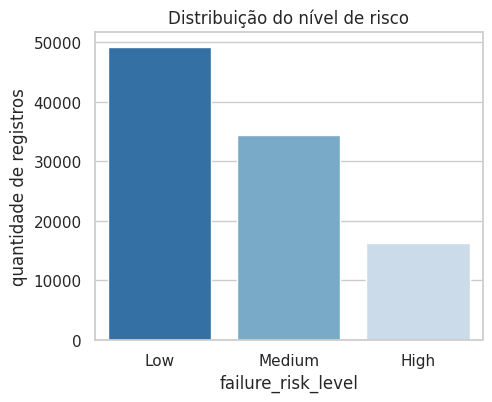

In [13]:
plt.figure(figsize=(5,4))
sns.countplot(x=coluna_risco, data=df, order=df[coluna_risco].value_counts().index, palette="Blues_r")
plt.title("Distribuição do nível de risco")
plt.xlabel(coluna_risco)
plt.ylabel("quantidade de registros")
plt.show()

## 5. Preparação dos dados

Usamos apenas as decisões conhecidas antes de a unidade existir: região, tipo de servidor, refrigeração, fonte de energia e a idade planejada do equipamento.

In [14]:
colunas_decisao = [coluna_regiao, coluna_server_type, coluna_cooling, coluna_energia, coluna_idade]
colunas_decisao = list(dict.fromkeys(colunas_decisao))  # remove duplicadas mantendo a ordem

df_prep = df.dropna(subset=[coluna_risco, coluna_custo]).copy()
df_prep = df_prep.drop_duplicates()

print("Colunas de decisão usadas:", colunas_decisao)
print("Formato após limpeza:", df_prep.shape)

Colunas de decisão usadas: ['datacenter_region', 'server_type', 'cooling_type', 'energy_source_primary', 'server_age_years']
Formato após limpeza: (100000, 35)


In [15]:
X = df_prep[colunas_decisao].copy()

colunas_texto = X.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X, columns=colunas_texto, drop_first=True)

le_risco = LabelEncoder()
y_risco = le_risco.fit_transform(df_prep[coluna_risco].astype(str))

y_custo = df_prep[coluna_custo]

print("Classes de risco:", list(le_risco.classes_))
print("Formato de X:", X.shape)

Classes de risco: ['High', 'Low', 'Medium']
Formato de X: (100000, 12)


In [16]:
X_train, X_test, y_risco_train, y_risco_test, y_custo_train, y_custo_test = train_test_split(
    X, y_risco, y_custo, test_size=0.2, random_state=42, stratify=y_risco
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)

Treino: (80000, 12)  Teste: (20000, 12)


## 6. Modelo de risco

Um Random Forest para classificar o nível de risco a partir das decisões de projeto.

In [17]:
modelo_risco = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
modelo_risco.fit(X_train, y_risco_train)

y_risco_pred = modelo_risco.predict(X_test)

print(f"Acurácia: {accuracy_score(y_risco_test, y_risco_pred):.2%}")
print()
print(classification_report(y_risco_test, y_risco_pred, target_names=le_risco.classes_))

Acurácia: 91.19%

              precision    recall  f1-score   support

        High       0.77      0.90      0.83      3254
         Low       0.95      0.98      0.96      9850
      Medium       0.94      0.82      0.87      6896

    accuracy                           0.91     20000
   macro avg       0.89      0.90      0.89     20000
weighted avg       0.92      0.91      0.91     20000



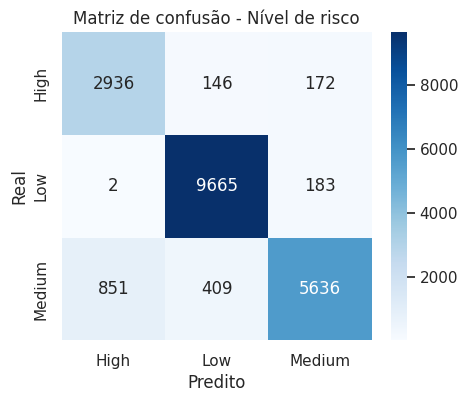

In [18]:
cm = confusion_matrix(y_risco_test, y_risco_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le_risco.classes_, yticklabels=le_risco.classes_)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão - Nível de risco")
plt.show()

## 7. Modelo de custo

Um segundo Random Forest, de regressão, para estimar o custo a partir das mesmas decisões de projeto.

In [19]:
modelo_custo = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_custo.fit(X_train, y_custo_train)

y_custo_pred = modelo_custo.predict(X_test)

print(f"R²: {r2_score(y_custo_test, y_custo_pred):.4f}")
print(f"Erro médio absoluto: {mean_absolute_error(y_custo_test, y_custo_pred):.2f}")

R²: 0.9324
Erro médio absoluto: 3.16


## 8. Eixo tempo: risco ao longo dos anos

Tratamos o eixo tempo como o ciclo de vida do equipamento: à medida que os servidores envelhecem, o risco de falha muda. Isso ajuda a planejar quando renovar o equipamento da nova unidade.

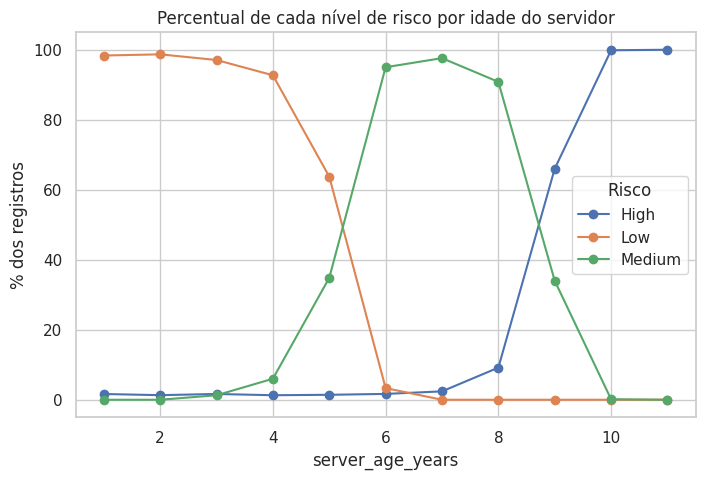

In [20]:
risco_por_idade = pd.crosstab(df_prep[coluna_idade], df_prep[coluna_risco], normalize="index") * 100

risco_por_idade.plot(kind="line", figsize=(8,5), marker="o")
plt.title("Percentual de cada nível de risco por idade do servidor")
plt.xlabel(coluna_idade)
plt.ylabel("% dos registros")
plt.legend(title="Risco")
plt.show()

## 9. Fatores mais importantes na decisão

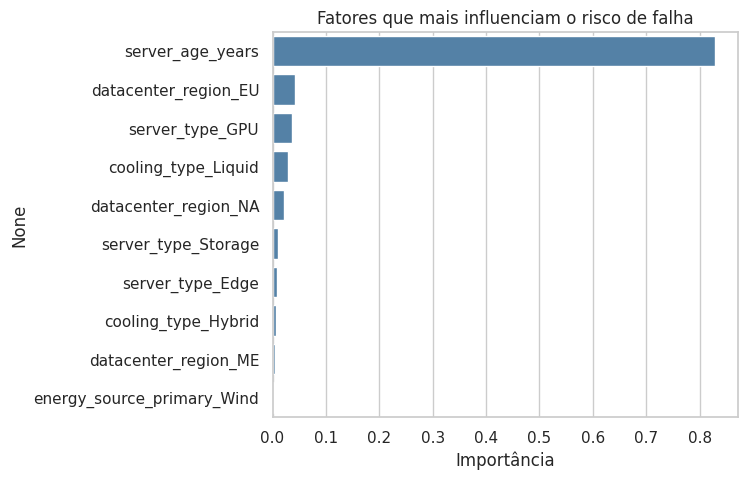

In [21]:
importancias = pd.Series(modelo_risco.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(6,5))
sns.barplot(x=importancias.values, y=importancias.index, color="steelblue")
plt.title("Fatores que mais influenciam o risco de falha")
plt.xlabel("Importância")
plt.show()

## 10. Conclusão do MVP

**O que o sistema faz:** a partir de decisões que a empresa toma antes de construir (região, tipo de servidor, refrigeração e fonte de energia) e da idade planejada do equipamento, o sistema estima o **nível de risco de falha** e o **custo operacional** esperado da nova unidade, e mostra como o risco evolui ao longo dos anos.

**Como apoia a decisão de implementar a nova unidade:**
- Antes de escolher onde construir, a empresa pode simular diferentes combinações de região, refrigeração e fonte de energia e comparar o risco e o custo previstos de cada uma
- O gráfico de risco por idade ajuda a planejar com antecedência quando será necessário orçar a renovação do equipamento
- O gráfico de fatores mais importantes mostra em que decisão de projeto vale mais a pena investir atenção

**Limitações desta primeira versão (MVP):**
- A base é sintética (simulada), então as relações encontradas refletem o processo de simulação, não necessariamente um data center real
- A coluna de custo usada é um custo operacional, não o investimento total de construção (não há custo de terreno, obra ou licenças na base)
- A base não tem prazo de obra, então o eixo tempo foi tratado como ciclo de vida do equipamento, não como cronograma de construção
- Apenas um modelo foi testado para cada tarefa, sem comparação com outros algoritmos nem ajuste fino de hiperparâmetros

**Próximos passos (evolução do MVP):**
- Testar outros algoritmos e comparar o desempenho
- Incluir custo de investimento inicial (CAPEX) e prazo real de construção
- Simular várias combinações de região, refrigeração e energia e recomendar a melhor de acordo com o quanto a empresa valoriza risco versus custo
- Validar as previsões com dados reais de data centers antes de qualquer decisão de investimento